***URL : https://www.kaggle.com/competitions/digit-recognizer/overview***

In [1]:
import numpy as np
import pandas as pd
import warnings

import torch
import torch.nn as nn
import torch.optim
from torch.utils.data import DataLoader, TensorDataset

import seaborn as sns
import matplotlib.pyplot as plt
warnings.simplefilter(action = 'ignore')

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 28

In [4]:
dataset = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/Digit_Recognizer/train.csv')
y_train = dataset['label']
dataset.drop(columns = 'label',inplace = True)


In [5]:
def preprocess(raw_image):
    image = torch.tensor(raw_image.values,dtype = torch.float32)
    image = image.reshape(1,IMAGE_SIZE,IMAGE_SIZE)
    image = image / 255.0
    return image
X_train = torch.tensor(np.array([preprocess(dataset.loc[row]) for row in range(dataset.shape[0])]))
y_train = torch.tensor(y_train)

In [ ]:
def preprocess(raw_image):
    image = torch.tensor(raw_image.values,dtype = torch.float32)
    image = image.reshape(1,IMAGE_SIZE,IMAGE_SIZE)
    image = image / 255.0
    return image
def build_batch(df : TensorDataset,is_shuffle = True):
    return DataLoader(
        df,
        batch_size = BATCH_SIZE,
        shuffle = is_shuffle,
        pin_memory = True,
    )
X_train = torch.tensor(np.array([preprocess(dataset.loc[row]) for row in range(dataset.shape[0])]))
y_train = torch.tensor(y_train)

In [7]:
dataset = build_batch(TensorDataset(X_train,y_train))

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.Conv = nn.Sequential(
            nn.Conv2d(in_channels = 1,out_channels = 32,kernel_size = 3,stride = 1,padding = 'same'),
            nn.MaxPool2d(kernel_size = 3,stride = 2,padding = 0),
            
            nn.Conv2d(in_channels = 32,out_channels = 64,kernel_size = 3,stride = 1,padding = 'same'),
            nn.MaxPool2d(kernel_size = 3,stride = 2,padding = 0),
            
            nn.Conv2d(in_channels = 64,out_channels = 128,kernel_size = 3,stride = 1,padding = 'same'),
            nn.MaxPool2d(kernel_size = 3,stride = 2,padding = 0),
        )
        self.flatten = nn.Flatten()
        self.MLP = nn.Sequential(
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            
            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            
            nn.Linear(128,64,bias = True),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            
            nn.Linear(64,10,bias = True),
        )
    def forward(self,X):
        X = self.Conv(X)
        X = self.flatten(X)
        X = self.MLP(X)
        return X

In [9]:
model = CNN()
model = model.to(device)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.01)

epochs = 25
total_loss = np.ndarray(shape = (epochs,),dtype = np.float32)
for epoch in range(epochs):
    sum_loss = 0.0
    for X_batch,y_batch in dataset:
        
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        
        preds = model(X_batch)
        loss = loss_func(preds,y_batch)
        sum_loss += loss.item()
        
        loss.backward()
        optimizer.step()
    res = sum_loss / len(dataset)
    print(f"Loss of epoch {epoch} : {res}")
    total_loss[epoch] = np.float32(res)

Loss of epoch 0 : 0.19616531686515457
Loss of epoch 1 : 0.09839751993841332
Loss of epoch 2 : 0.07168281373417772
Loss of epoch 3 : 0.062238152448568666
Loss of epoch 4 : 0.05272480141067727
Loss of epoch 5 : 0.051722197340918305
Loss of epoch 6 : 0.04516739779308933
Loss of epoch 7 : 0.042177517922663506
Loss of epoch 8 : 0.032783566948690245
Loss of epoch 9 : 0.03442253841423302
Loss of epoch 10 : 0.035177886854578226
Loss of epoch 11 : 0.03046481190191942
Loss of epoch 12 : 0.029053752285210722
Loss of epoch 13 : 0.024085044595720407
Loss of epoch 14 : 0.026124916968469598
Loss of epoch 15 : 0.02465333415053639
Loss of epoch 16 : 0.02298191068304679
Loss of epoch 17 : 0.021185449139781418
Loss of epoch 18 : 0.019456009579380786
Loss of epoch 19 : 0.018294235011943428
Loss of epoch 20 : 0.018668047115010935
Loss of epoch 21 : 0.020623718290282724
Loss of epoch 22 : 0.014992074019094323
Loss of epoch 23 : 0.013787460215902702
Loss of epoch 24 : 0.015050528392949942


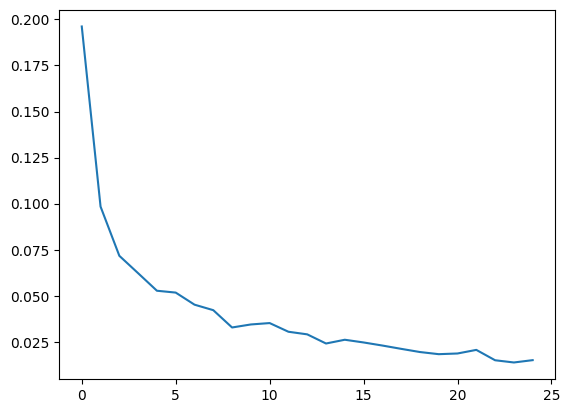

In [10]:
plt.plot(np.arange(len(total_loss)),total_loss)
plt.show()

In [12]:
X_test = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/Digit_Recognizer/test.csv')
X_test = torch.tensor(np.array([preprocess(X_test.loc[row]) for row in range(X_test.shape[0])]))
X_test = build_batch(X_test,is_shuffle = False)

In [ ]:
preds = []
for X_batch in X_test:
    X_batch = X_batch.to(device)
    with torch.no_grad():
        raw_pred = model(X_batch)
        prob = torch.nn.functional.softmax(raw_pred,dim = 1)
        pred = torch.argmax(prob,dim = 1)
        #print(pred)
        for i in pred:
            preds.append(float(i))


In [ ]:
submission = pd.DataFrame({
    'ImageId' : [(id + 1) for id in range(len(preds))],
    'Label' : preds,
})
submission.to_csv('submission.csv',index = False)